### Merge Image Files With Text

```
여러 이미지 PNG 파일을 세로로 이어붙이는 (겹쳐지는 부분 없음. 세로(여러 이미지 파일의 세로가 합산된 크기), 가로(여러 이미지 파일 중에서 최대 크기)) Python Code를 만들어줘
```

#### Example - 포켓몬스터 무인편 131화 '로사와 해피너스 눈물어린 우정'

In [8]:
import os
from PIL import Image

def merge_images_vertically(image_folder, output_name="merged_image.png"):
    # 1. 폴더 내의 png 파일 목록 가져오기 (이름순 정렬)
    file_list = [f for f in os.listdir(image_folder) if f.lower().endswith('.png')]
    file_list.sort()
    
    if not file_list:
        print("이미지 파일이 없습니다.")
        return

    images = [Image.open(os.path.join(image_folder, x)) for x in file_list]

    # 2. 결과물 사이즈 계산
    # 가로: 이미지들 중 최대 가로 길이
    # 세로: 모든 이미지의 세로 길이 합산
    widths, heights = zip(*(i.size for i in images))

    max_width = max(widths)
    total_height = sum(heights)

    # 3. 빈 캔버스 생성 (RGBA 모드로 투명도 유지)
    new_im = Image.new('RGBA', (max_width, total_height))

    # 4. 이미지 붙여넣기
    y_offset = 0
    for im in images:
        # 이미지를 캔버스에 붙임 (중앙 정렬을 원치 않으면 (0, y_offset) 사용)
        new_im.paste(im, (0, y_offset))
        y_offset += im.size[1]

    # 5. 저장
    new_im.save(output_name)
    print(f"성공! '{output_name}'으로 저장되었습니다. (사이즈: {max_width}x{total_height})")
    
    return new_im
# 사용 예시


In [10]:
image_folder = './images'
output_name = './images/merged_image.png'
new_im = merge_images_vertically(image_folder, output_name=output_name)

성공! './images/merged_image.png'으로 저장되었습니다. (사이즈: 344x4045)


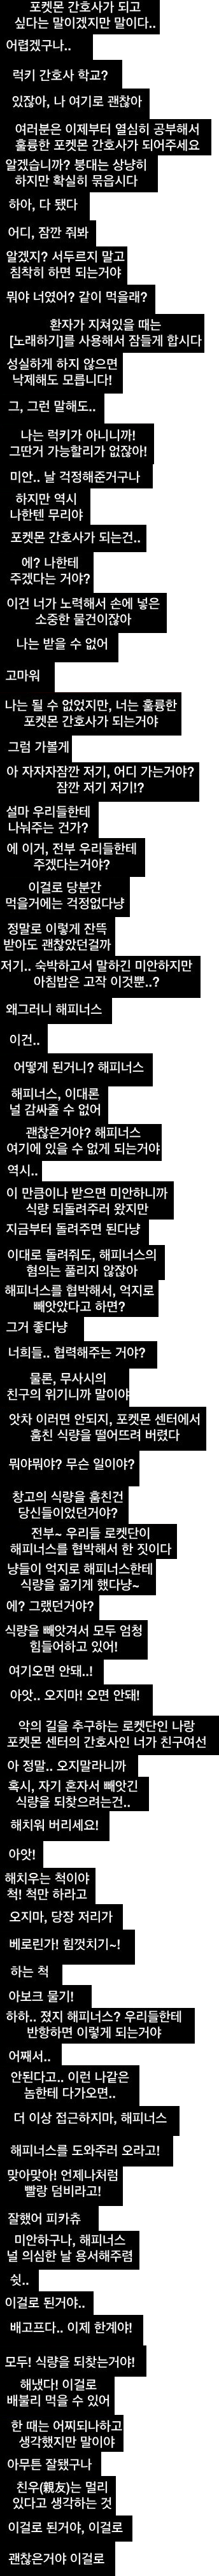

In [11]:
new_im